In [124]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Разведовательный анализ. Базовый анализ 

In [125]:
tmp_data = pd.read_csv('data/Run200_Wave_0_1.txt', sep=' ', header=None, skipinitialspace=True)

# удаляем технические столбцы 
tmp_data = tmp_data.drop([0, 1, 2, 3, 504], axis=1)

In [126]:
go_data = tmp_data.copy()

In [127]:
go_data.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23479 entries, 0 to 23478
Data columns (total 500 columns):
 #    Column  Dtype
---   ------  -----
 0    4       int64
 1    5       int64
 2    6       int64
 3    7       int64
 4    8       int64
 5    9       int64
 6    10      int64
 7    11      int64
 8    12      int64
 9    13      int64
 10   14      int64
 11   15      int64
 12   16      int64
 13   17      int64
 14   18      int64
 15   19      int64
 16   20      int64
 17   21      int64
 18   22      int64
 19   23      int64
 20   24      int64
 21   25      int64
 22   26      int64
 23   27      int64
 24   28      int64
 25   29      int64
 26   30      int64
 27   31      int64
 28   32      int64
 29   33      int64
 30   34      int64
 31   35      int64
 32   36      int64
 33   37      int64
 34   38      int64
 35   39      int64
 36   40      int64
 37   41      int64
 38   42      int64
 39   43      int64
 40   44      int64
 41   45      int64
 42   46  

In [128]:
go_data.columns = list(range(500))

# 2**14 - разрядность детектора 
# 1560  - аппаратное смещение - поггрешность прибора 
go_data = 2**14 - go_data - 1560 

## 2.1 Выделение сигнала

In [129]:
go_data.head(5)

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
0,4,1,0,2,6,4,0,2,4,4,...,-4,2,9,9,7,5,4,2,4,5
1,4,2,4,-2,0,2,4,2,1,3,...,-4,7,0,2,0,5,4,5,2,4
2,4,4,2,-1,4,0,0,5,1,0,...,4,3,4,4,6,3,1,4,4,3
3,-4,2,6,0,0,2,4,2,0,4,...,0,-2,2,3,4,-4,4,2,1,2
4,1,9,1,3,-3,4,1,0,8,3,...,4,4,1,-4,0,4,0,0,2,-1


In [130]:
go_data.describe()

,0,1,2,3,4,5,6,7,8,9,...,490,491,492,493,494,495,496,497,498,499
count,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,...,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000,23479.000000
mean,1.027684,1.041526,1.029984,1.010009,0.996039,1.021381,1.031390,1.045530,1.036330,1.031092,...,1.670983,1.684314,1.727927,1.828272,1.742877,1.682908,1.720601,1.721837,1.712211,1.716257
std,2.805884,2.833516,2.840755,2.852066,2.833412,2.836271,2.831241,2.827526,2.846291,2.814655,...,3.357997,3.373568,3.340707,3.332547,3.290301,3.232245,3.268458,3.251192,3.253340,3.242307
min,-10.000000,-11.000000,-10.000000,-11.000000,-10.000000,-11.000000,-11.000000,-9.000000,-10.000000,-10.000000,...,-12.000000,-11.000000,-10.000000,-12.000000,-9.000000,-10.000000,-9.000000,-10.000000,-9.000000,-11.000000
25%,0.000000,0.000000,-1.000000,-1.000000,-1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
75%,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,3.000000,...,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000,4.000000
max,12.000000,12.000000,12.000000,13.000000,12.000000,12.000000,12.000000,13.000000,12.000000,15.000000,...,24.000000,26.000000,22.000000,28.000000,22.000000,23.000000,26.000000,20.000000,24.000000,22.000000


### Этап 1. Определение точки старта

"Формально область, названную сигналом, можно обозначить следующим образом:" 

$𝑆𝑖𝑔𝑛𝑎𝑙_𝑗=𝑅𝑎𝑤 𝐷𝑎𝑡𝑎_𝑗[𝑖_{𝑚𝑎𝑥};𝑖_{𝑚𝑗+3_𝜎𝑗}]$

Смотрим весь диапазон сиггналов 

In [131]:
peak_positions = go_data.idxmax(axis=1)
print(peak_positions.describe())

count    23479.000000
mean       149.628604
std          2.489996
min        145.000000
25%        149.000000
50%        150.000000
75%        151.000000
max        472.000000
dtype: float64


Центрируем пик для каждой строки 

In [132]:
peak_commponents = []

for index, row in go_data.iterrows():
    row_peak_positions = row.idxmax()
    row_std = row.std()

    peak_pulse = row.values[ row_peak_positions - 6: row_peak_positions + 10] # type: ignore
    
    peak_commponents.append(peak_pulse)





go_peak = pd.DataFrame(peak_commponents)


display(go_peak)

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
0,6,4,10,61,261,446,533,446,364,292,217,194,143,92,83,76
1,5,5,12,151,644,1389,1903,1785,1436,1072,768,551,398,288,204,151
2,14,42,266,937,1883,2484,2560,2044,1500,1065,722,532,372,288,203,194
3,8,4,0,44,194,397,566,527,464,345,250,188,156,124,84,61
4,0,10,34,193,820,1528,1796,1630,1326,949,663,468,337,253,215,178
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
23474,6,0,1,42,197,400,504,491,420,252,202,177,132,76,57,48
23475,10,29,110,605,2302,4428,5767,5666,4555,3431,2522,1841,1456,1102,843,673
23476,12,38,108,683,2245,4013,4999,4540,3552,2645,1888,1424,1108,893,660,587
23477,1,0,24,205,672,1226,1457,1340,1044,784,596,465,334,247,204,174


Text(0, 0.5, 'Частота')

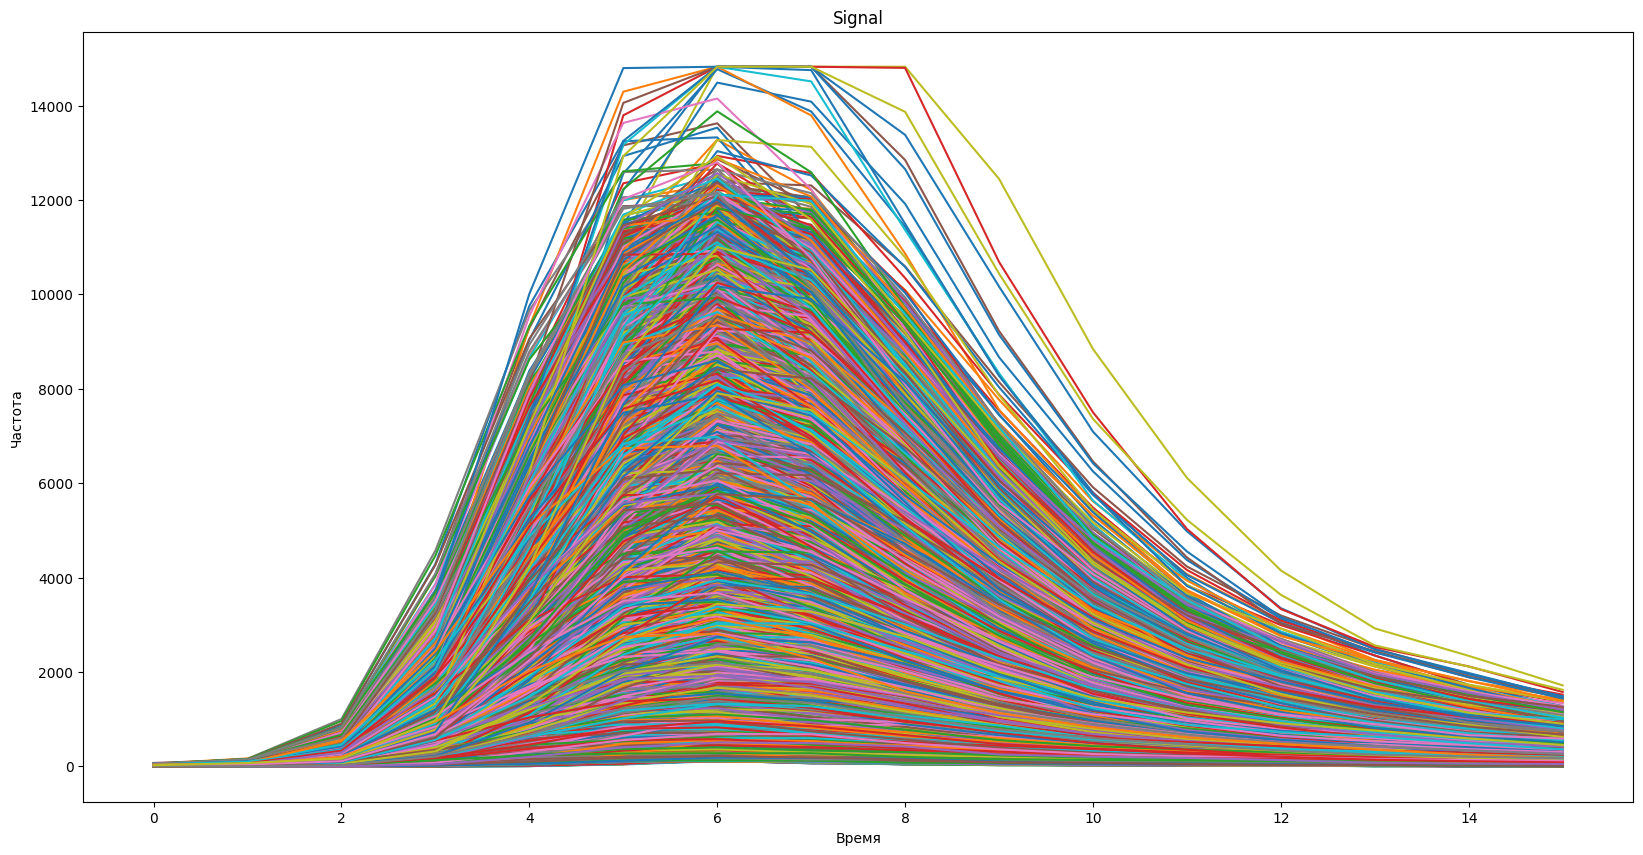

In [140]:
ax = go_peak.T.plot(title='Signal' ,legend=None,figsize=(20,10))

ax.set_xlabel('Время')
ax.set_ylabel('Частота')


In [134]:
#Выберем жесткий диапазон 140-165 где идентифицируется синал
#go_data = go_data[140:165]

In [ ]:
go_features = pd.DataFrame( ) # создаем пустой DF 


go_features['MEAN'] = go_data.mean(axis=1)

go_features['STD'] = go_data.std(axis=1)

go_features['SKEWNESS'] = go_data.skew(axis=1)

go_features['KURTOSIS'] = go_data.kurt(axis=1)

go_features['MAX_VAL'] = go_data.max(axis=1)

go_features['LONG_AREA'] = go_data.sum(axis=1) # вообще надо брать площадь, но для итоговогго расчета будет отношение площадей, поэтому оставим сумму 

go_features['SHORT_AREA'] = go_peak.sum(axis=1) # берем из df который ограничили выше

go_features['PSD'] = ( go_features['LONG_AREA'] - go_features['SHORT_AREA'] ) / go_features['LONG_AREA']

go_features['MAX_DIFF'] = go_data.diff(axis=1).max(axis=1)
    


In [136]:
display(go_features)
print(go_features.shape)

,MEAN,STD,SKEWNESS,KURTOSIS,MAX_VAL,LONG_AREA,SHORT_AREA,PSD,MAX_DIFF
0,12.098,46.208472,8.233707,73.983010,533,6049,3228,0.466358,200.0
1,26.226,163.272112,8.963585,85.801618,1903,13113,10762,0.179288,745.0
2,35.990,225.369832,8.896459,84.307518,2560,17995,15106,0.160545,946.0
3,10.556,50.120565,8.437774,77.168438,566,5278,3412,0.353543,203.0
4,25.782,156.545416,8.889409,83.897228,1796,12891,10400,0.193236,708.0
...,...,...,...,...,...,...,...,...,...
23474,6.498,45.303364,8.765057,82.264733,504,3249,3005,0.075100,203.0
23475,91.518,519.993176,8.566334,78.858213,5767,45759,35340,0.227693,2126.0
23476,78.894,433.006554,8.631773,80.550306,4999,39447,29395,0.254823,1768.0
23477,25.666,128.886671,8.477362,77.800549,1457,12833,8773,0.316372,554.0


(23479, 9)


Построим PSD  гистрограмму 

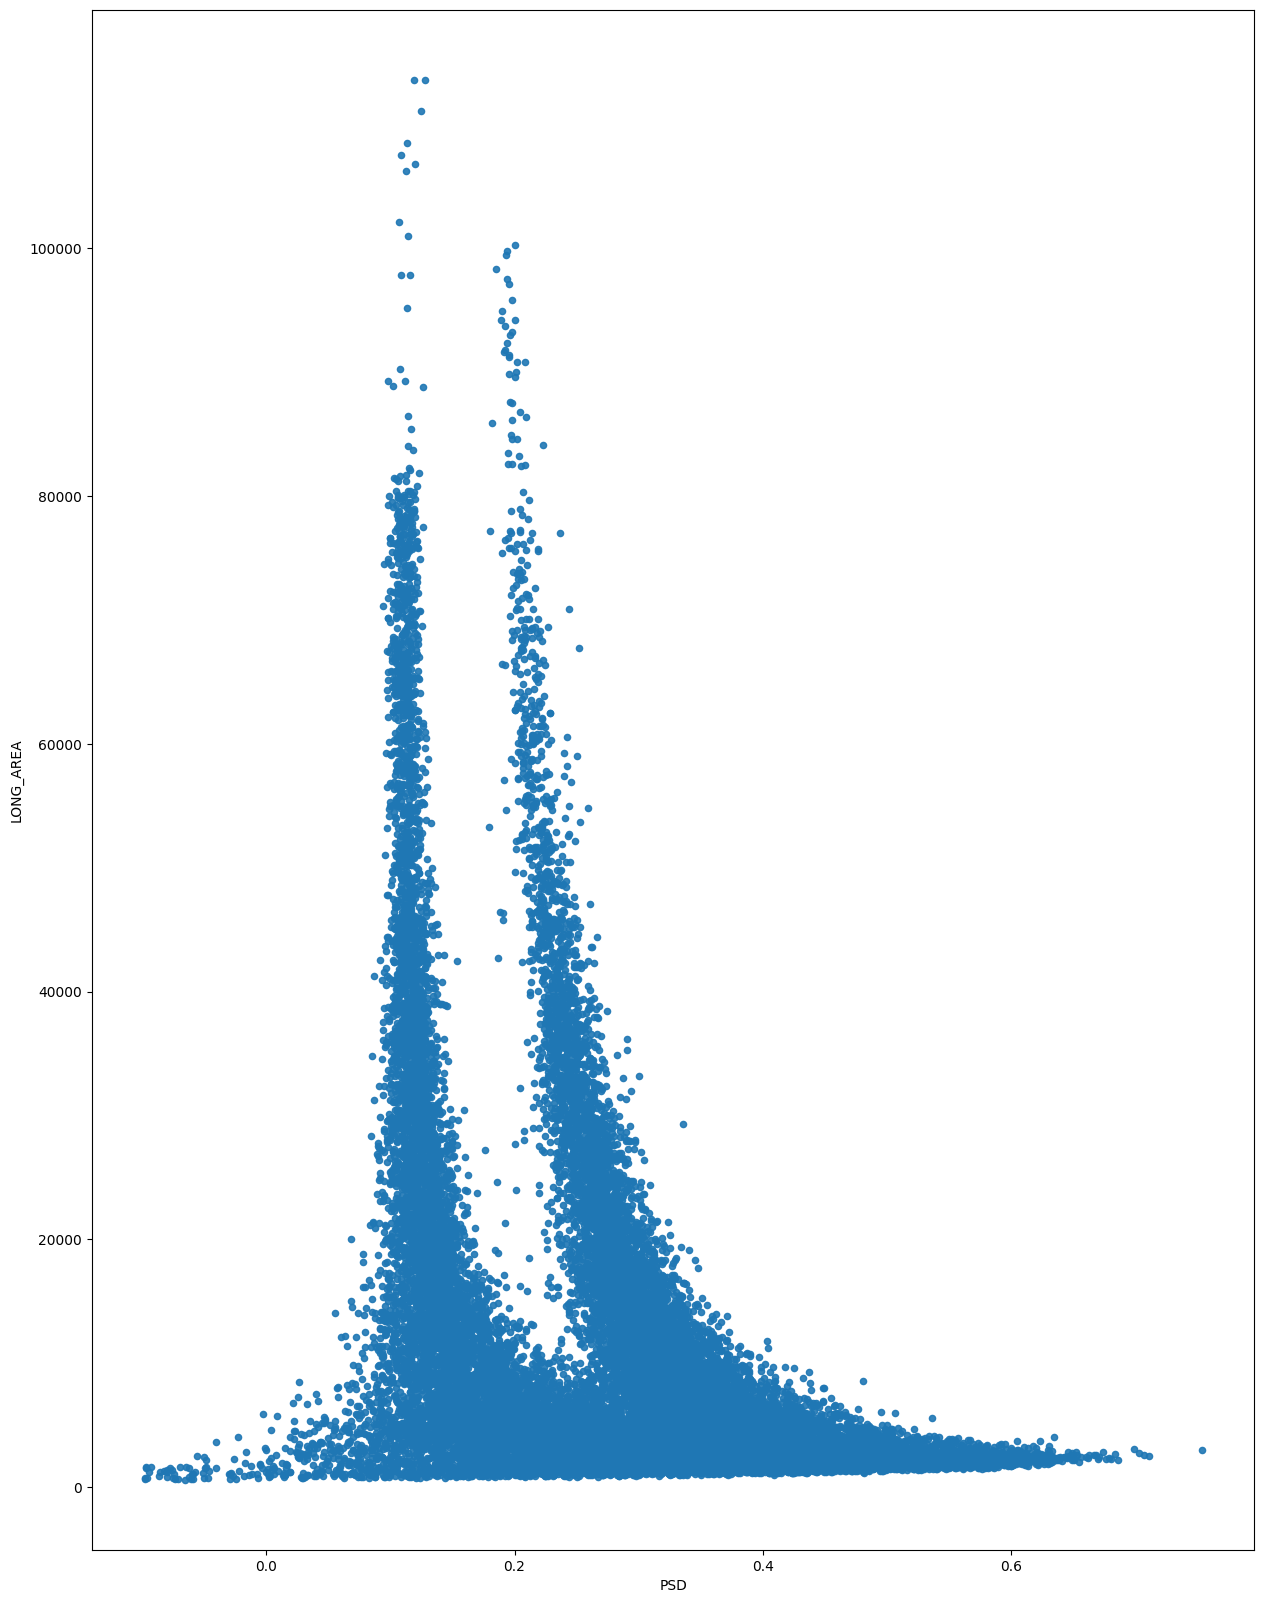

In [137]:
go_features[go_features['PSD'] > -0.1].plot.scatter(
    y='LONG_AREA', 
    x='PSD', 
    alpha=0.9, 
    figsize=(15, 20)
)
ax.set_title('Диаграмма #1')
ax.set_xlabel('LONG_AREA ')
ax.set_ylabel('PSD')
plt.show()

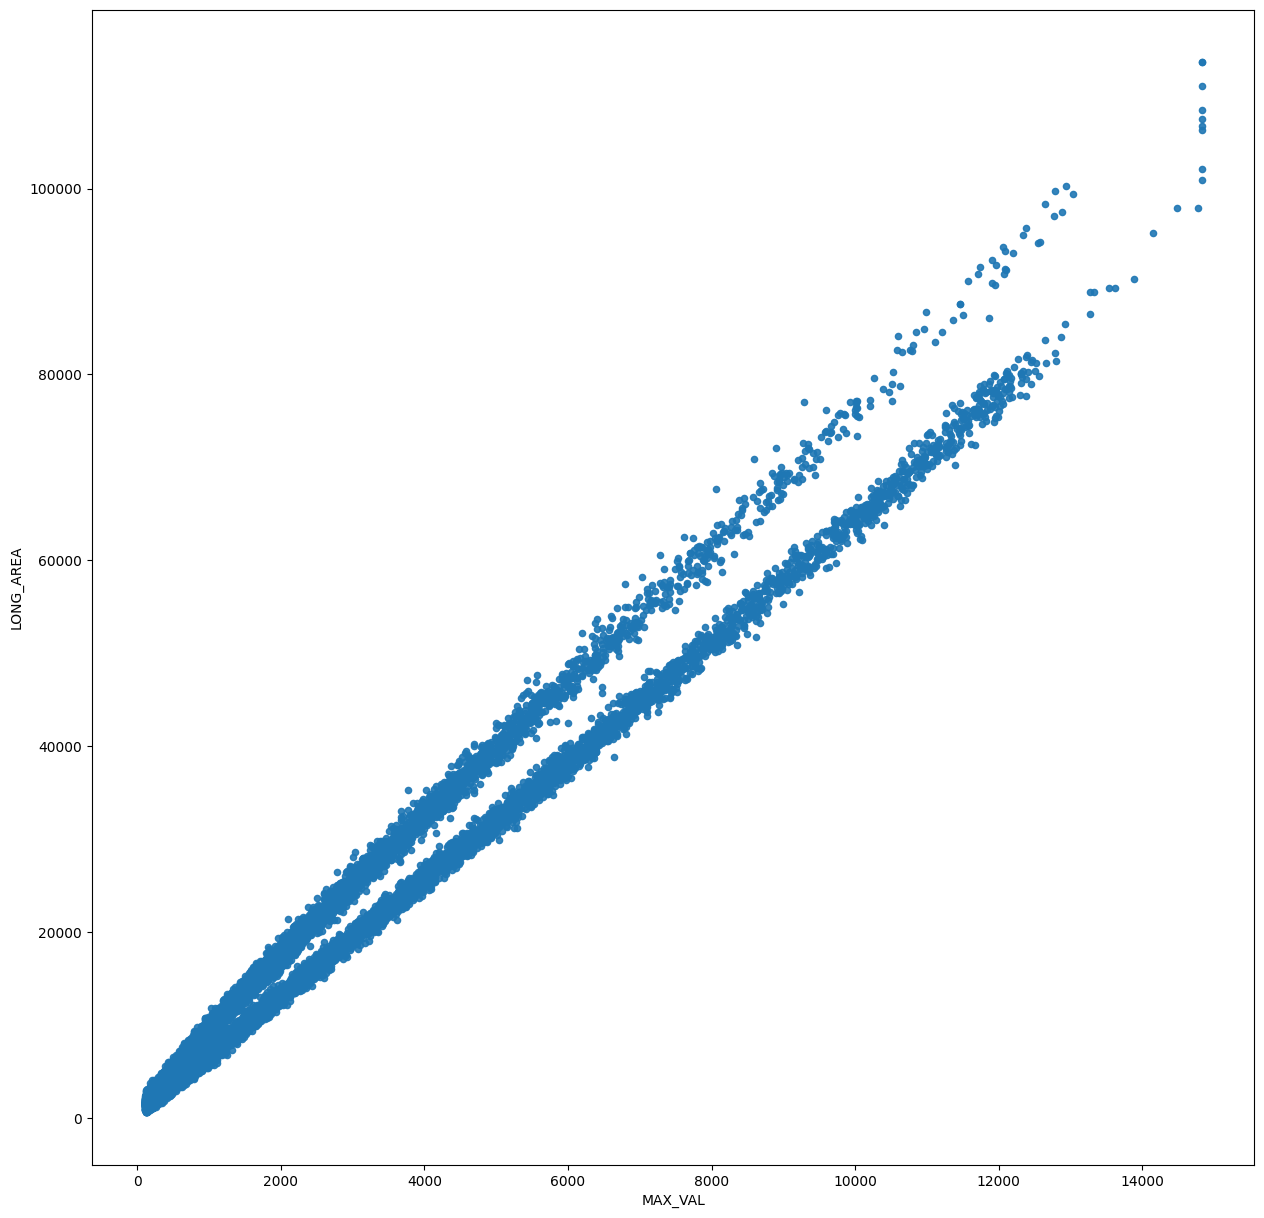

In [ ]:
go_features[go_features['PSD'] > -0.1].plot.scatter(
    y='LONG_AREA', 
    x='MAX_VAL', 
    alpha=0.9, 
    figsize=(15,15)
)
ax.set_title('Диаграмма #2')
ax.set_xlabel('MAX_VAL')
ax.set_ylabel('LONG_AREA')
plt.show()

Графики соответствуют теоретической части. 

In [139]:
go_features.to_csv('data/features.csv')